<a href="https://colab.research.google.com/github/edemers8/NEUR3002/blob/main/ClusteringActivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install spacy scikit-learn matplotlib seaborn ipywidgets
!python -m spacy download en_core_web_md

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 15.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"


📊 Cluster Assignments:
                   Word  Cluster     PCA_1     PCA_2
0          granny smith        0  1.243941  1.375767
1              plantain        4 -4.121243 -1.863001
2                 grape        2 -2.304003 -2.334622
3               emperor        1  5.015642 -1.715949
4               empress        0  0.120724  2.904117
5                prince        1  5.015642 -1.715949
6                infant        3 -2.173364  5.666563
7                potato        4 -3.670228 -3.616959
8  medical professional        1  0.872888  1.300033


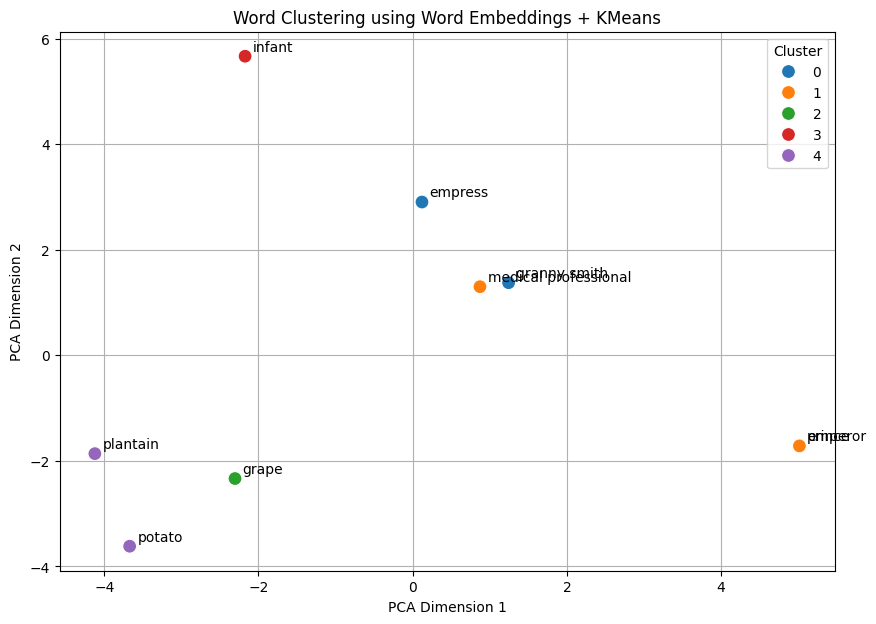

In [8]:
# 📦 Imports
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd

# 🧠 Load spaCy's medium English model (includes word vectors)
nlp = spacy.load("en_core_web_md")

# ✍️ Input: List of words to cluster
words = ["granny smith", "plantain", "grape", "emperor", "empress", "prince", "infant", "potato", "medical professional",]

# 🔢 Extract word vectors
word_vectors = [nlp(word).vector for word in words]

# ⚙️ Clustering using KMeans
k = 5  # Number of clusters — adjust as needed
kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
labels = kmeans.fit_predict(word_vectors)

# 🔍 Reduce dimensions for visualization (2D)
pca = PCA(n_components=2)
points_2d = pca.fit_transform(word_vectors)

# 🧾 Show cluster assignments as a table
df = pd.DataFrame({
    "Word": words,
    "Cluster": labels,
    "PCA_1": points_2d[:, 0],
    "PCA_2": points_2d[:, 1]
})
print("📊 Cluster Assignments:")
print(df)

# 🎨 Plot the clustered words
plt.figure(figsize=(10, 7))
sns.scatterplot(x=points_2d[:, 0], y=points_2d[:, 1], hue=labels, palette="tab10", s=100)

# Annotate each point with the word
for i, word in enumerate(words):
    plt.text(points_2d[i, 0]+0.1, points_2d[i, 1]+0.1, word)

plt.title("Word Clustering using Word Embeddings + KMeans")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()



